# 🎓 Otimização de Hiperparâmetros: Random Search × Hyperopt (TPE)
**Disciplina:** REDES NEURAIS ARTIFICIAIS, DEEP LEARNING E ALGORITMOS GENÉTICOS
**Curso:** Tecnólogo em Inteligência Artificial  

---

## 🎯 Objetivos de Aprendizagem

Ao final desta aula prática, você será capaz de entender:
1. Como os hiperparâmetros mudam o comportamento de uma LSTM.
2. Onde aparecem sinais de underfitting e overfitting.
3. Como o Random Search explora o espaço de busca.
4. Como o TPE do Hyperopt direciona a busca usando os resultados anteriores.
5. A melhor configuração encontrada realmente generaliza no conjunto de teste.

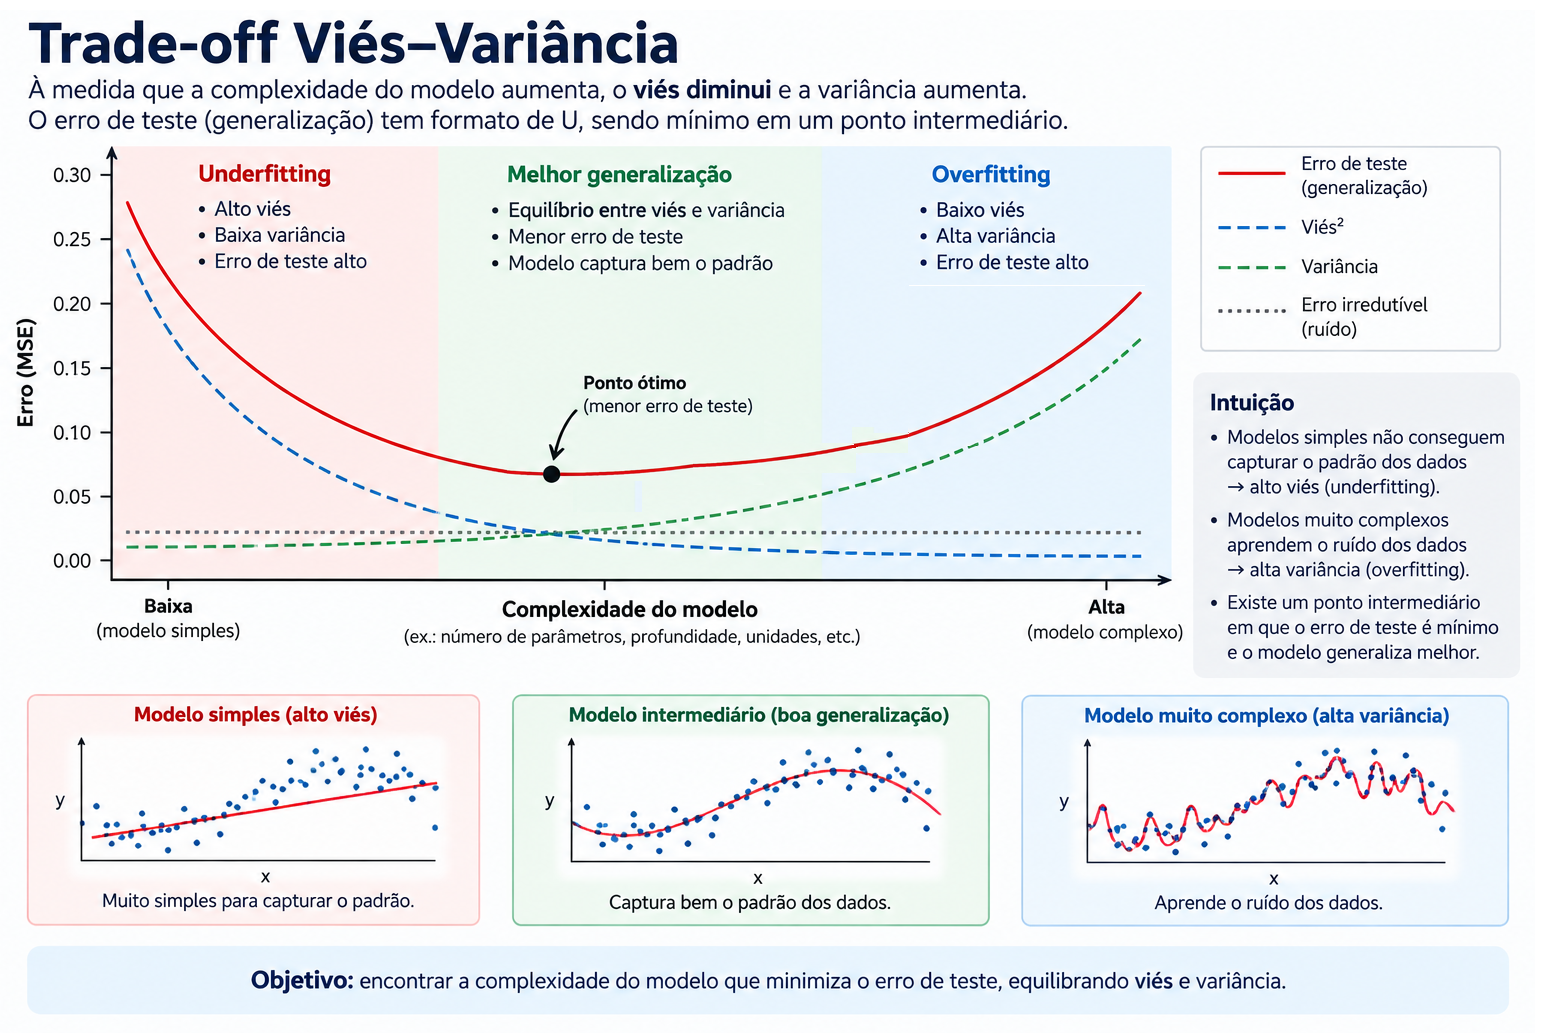

## 1. Dataset

Usaremos o **Power Consumption of Tetouan City**, do UCI Machine Learning Repository.

O conjunto contém 52.417 observações, com registros a cada 10 minutos. Neste notebook vamos prever **Zone 1 Power Consumption** para manter a construção da LSTM simples e concentrar a aula na otimização.

**Não é necessário fazer upload de arquivo no Colab:** o dataset será baixado diretamente do UCI.

In [ ]:
!pip -q install hyperopt ucimlrepo

In [ ]:
import os
import gc
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from hyperopt import hp, tpe, fmin, STATUS_OK, Trials, space_eval
from ucimlrepo import fetch_ucirepo

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

## 2. Download direto

`fetch_ucirepo(id=849)` baixa o dataset diretamente do UCI e evita qualquer dependência de upload manual.

In [ ]:
dataset = fetch_ucirepo(id=849)

features = dataset.data.features.copy()
targets = dataset.data.targets.copy()

df = pd.concat([features, targets], axis=1)

df["DateTime"] = pd.to_datetime(df["DateTime"])

df = df.sort_values("DateTime").reset_index(drop=True)

# Usar apenas as primeiras 10.000 observações
df = df.iloc[:5_000].copy()

print(f"Linhas: {len(df):,}")
print(f"Colunas: {len(df.columns)}")

display(df.head())

In [ ]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "únicos": df.nunique()
})

display(summary)

print("Período:")
print(df["DateTime"].min(), "→", df["DateTime"].max())

## 3. Visualização do sinal

Antes de otimizar, precisamos entender o que a LSTM terá de aprender.

Vamos observar a série em três escalas e também o perfil médio de consumo ao longo do dia.

In [ ]:
target = "Zone 1 Power Consumption"
serie = df[target]

fig, axes = plt.subplots(3, 1, figsize=(15, 11))

axes[0].plot(serie.iloc[:300], linewidth=1.5)
axes[0].set_title("Janela curta — comportamento local")
axes[0].set_ylabel("Consumo")
axes[0].grid(alpha=0.25)

axes[1].plot(serie.iloc[:576], linewidth=1.2)
axes[1].set_title("≈ 2 dias de observações")
axes[1].set_ylabel("Consumo")
axes[1].grid(alpha=0.25)

axes[2].plot(df["DateTime"], serie, linewidth=0.7)
axes[2].set_title("Série temporal completa")
axes[2].set_xlabel("Data")
axes[2].set_ylabel("Consumo")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
perfil_hora = (
    df.assign(hour=df["DateTime"].dt.hour)
      .groupby("hour")[target]
      .mean()
)

plt.figure(figsize=(13, 4.5))
plt.plot(perfil_hora.index, perfil_hora.values, marker="o", linewidth=2)
plt.fill_between(perfil_hora.index, perfil_hora.values, alpha=0.15)
plt.xticks(range(24))
plt.xlabel("Hora do dia")
plt.ylabel("Consumo médio")
plt.title("Perfil médio de consumo ao longo do dia")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 4. Preparação temporal

Com `WINDOW = 48`, usamos as 48 observações anteriores para prever o próximo ponto.

Como cada observação representa 10 minutos:

**48 pontos = 8 horas de histórico.**

### Regra importante para séries temporais

A divisão deve respeitar a ordem temporal:

**passado → treino | futuro próximo → validação | futuro → teste**

Além disso, o scaler será ajustado **somente no treino**, evitando data leakage.

In [ ]:
MAX_ROWS = 50_000
WINDOW = 48

df_model = df.iloc[:MAX_ROWS].copy()
values_raw = df_model[target].to_numpy(dtype=np.float32)

n = len(values_raw)
train_end_raw = int(0.70 * n)
val_end_raw = int(0.85 * n)

scaler = MinMaxScaler()
scaler.fit(values_raw[:train_end_raw].reshape(-1, 1))

values = scaler.transform(values_raw.reshape(-1, 1)).astype(np.float32)

X, y = [], []
for i in range(WINDOW, len(values)):
    X.append(values[i-WINDOW:i])
    y.append(values[i])

X = np.asarray(X, dtype=np.float32)
y = np.asarray(y, dtype=np.float32)

train_end = train_end_raw - WINDOW
val_end = val_end_raw - WINDOW

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(df_model["DateTime"], values_raw, linewidth=0.8)

plt.axvspan(
    df_model["DateTime"].iloc[0],
    df_model["DateTime"].iloc[train_end_raw],
    alpha=0.12, label="Treino",
    color="green"
)

plt.axvspan(
    df_model["DateTime"].iloc[train_end_raw],
    df_model["DateTime"].iloc[val_end_raw],
    alpha=0.12, label="Validação",
    color="orange"
)

plt.axvspan(
    df_model["DateTime"].iloc[val_end_raw],
    df_model["DateTime"].iloc[-1],
    alpha=0.12, label="Teste",
    color="red"
)

plt.title("Divisão temporal: passado → validação → futuro")
plt.xlabel("Data")
plt.ylabel("Consumo")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 5. Espaço de hiperparâmetros

O foco da aula é a busca por:

| Hiperparâmetro | Papel |
|---|---|
| `units` | capacidade da LSTM |
| `dropout` | regularização |
| `learning_rate` | tamanho do passo de otimização |
| `batch_size` | quantidade de amostras por atualização |

### Intuição

- poucos `units` podem gerar underfitting;
- muitos `units` aumentam a capacidade e também o risco de overfitting;
- `dropout` ajuda a regularizar;
- `learning_rate` muito alto pode tornar o treinamento instável;
- `learning_rate` muito baixo pode tornar o treinamento lento.

In [ ]:
# TODO defina o espaço de busca dos hiperparâmetros que serão testados.
# "units" e "batch_size" usam valores discretos; "dropout" e "learning_rate"
# definem intervalos nos quais os valores podem ser amostrados.
SEARCH_SPACE = {
    # TODO permita testar 16, 32, 64 ou 128 unidades na camada Dense.
    "units": ...,

    # TODO permita valores de dropout entre 0.0 e 0.5.
    "dropout": ...,

    # TODO permita valores de learning rate entre 1e-5 e 1e-2.
    "learning_rate": ...,

    # TODO permita batch sizes de 32, 64 ou 128.
    "batch_size": ...,
}


# TODO defina o número de tentativas de hiperparâmetros que serão avaliadas.
N_TRIALS = ...

# TODO defina o número de épocas usado durante cada tentativa do tuning.
TUNING_EPOCHS = ...

# TODO defina o número de épocas usado para treinar o modelo final
# após a escolha dos melhores hiperparâmetros.
FINAL_EPOCHS = ...

In [ ]:
# TODO crie um modelo Sequential para previsão usando uma sequência temporal
# com WINDOW passos e uma única variável por passo.
def create_lstm(units, dropout, learning_rate):
    model = keras.Sequential([
        # TODO adicione uma camada Input com shape=(WINDOW, 1).
        ...,

        # TODO adicione uma camada LSTM usando o número de unidades definido em units.
        ...,

        # TODO adicione Dropout usando a taxa definida em dropout.
        ...,

        # TODO adicione uma camada Dense de saída com 1 neurônio.
        ...
    ])

    # TODO compile o modelo usando Adam com learning_rate definido em learning_rate
    # e loss="mse" para uma tarefa de regressão.
    ...
    return model

In [ ]:
def train_one_config(params, verbose=0):
    keras.backend.clear_session()
    gc.collect()

    # TODO crie o modelo LSTM usando os hiperparâmetros armazenados em params:
    # units, dropout e learning_rate.
    model = create_lstm(...)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        )
    ]

    start = time.time()

    # TODO treine o modelo usando X_train e y_train.
    # TODO valide com validation_data=(X_val, y_val), use epochs=TUNING_EPOCHS,
    # batch_size=int(params["batch_size"]), verbose=verbose e callbacks=callbacks.
    history = ...

    elapsed = time.time() - start

    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    best_val = float(np.min(history.history["val_loss"]))
    best_train = float(history.history["loss"][best_epoch - 1])

    return {
        "model": model,
        "history": history,
        "best_val_loss": best_val,
        "best_train_loss": best_train,
        "best_epoch": best_epoch,
        "time_seconds": elapsed
    }

In [ ]:
def train_demo_config(params, epochs=30):

    keras.backend.clear_session()
    gc.collect()

    model = create_lstm(
        units=params["units"],
        dropout=params["dropout"],
        learning_rate=params["learning_rate"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=int(params["batch_size"]),
        verbose=0,
        shuffle=False
    )

    best_epoch = int(np.argmin(history.history["val_loss"])) + 1

    return {
        "model": model,
        "history": history,
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "best_epoch": best_epoch
    }

# 6. Laboratório visual: underfitting × overfitting

Antes das buscas automáticas, vamos treinar três configurações deliberadamente diferentes.

A intenção é criar uma referência visual para interpretar os resultados da otimização.

In [ ]:
demo_configs = {
    "Underfitting": {
        "units": 4, "dropout": 0.00, "learning_rate": 4e-8, "batch_size": 128
    },
    "Boa generalização": {
        "units": 16, "dropout": 0.10, "learning_rate": 7e-2, "batch_size": 128
    },
    "Overfitting": {
        "units": 16, "dropout": 0.00, "learning_rate": 3e-1, "batch_size": 128
    }
}

demo_results = {}

for name, params in demo_configs.items():

    result = train_demo_config(params, epochs=17)

    demo_results[name] = result

    print(
        f"{name}: "
        f"val_loss mínimo = {result['best_val_loss']:.5f} | "
        f"melhor época = {result['best_epoch']}"
    )

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)

for ax, (name, result) in zip(axes, demo_results.items()):
    h = result["history"].history

    ax.plot(h["loss"], label="Treino", linewidth=2)
    ax.plot(h["val_loss"], label="Validação", linewidth=2)
    ax.axvline(
        result["best_epoch"] - 1,
        linestyle="--",
        linewidth=1,
        label="Melhor época"
    )

    ax.set_title(name)
    ax.set_xlabel("Época")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("MSE")
axes[-1].legend()

plt.suptitle(
    "Configurações diferentes podem apresentar comportamentos de generalização diferentes",
    y=1.03
)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 4.8), sharey=True)

# remover Overffiting
if "Underfitting" in demo_results:
    demo_results.pop("Underfitting")

for ax, (name, result) in zip(axes, demo_results.items()):
    h = result["history"].history

    ax.plot(h["loss"], label="Treino", linewidth=2)
    ax.plot(h["val_loss"], label="Validação", linewidth=2)
    ax.axvline(
        result["best_epoch"] - 1,
        linestyle="--",
        linewidth=1,
        label="Melhor época"
    )
    ax.set_xlim(0, 33)
    ax.set_ylim(0, 0.005)
    ax.set_title(name)
    ax.set_xlabel("Época")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("MSE")
axes[-1].legend()

plt.suptitle(
    "Configurações diferentes podem apresentar comportamentos de generalização diferentes",
    y=1.03
)
plt.tight_layout()
plt.show()

# 7. Random Search

No Random Search, cada configuração é sorteada independentemente das anteriores.

A pergunta da aula é:

> **Quantas tentativas precisamos até encontrar uma região boa do espaço de hiperparâmetros?**

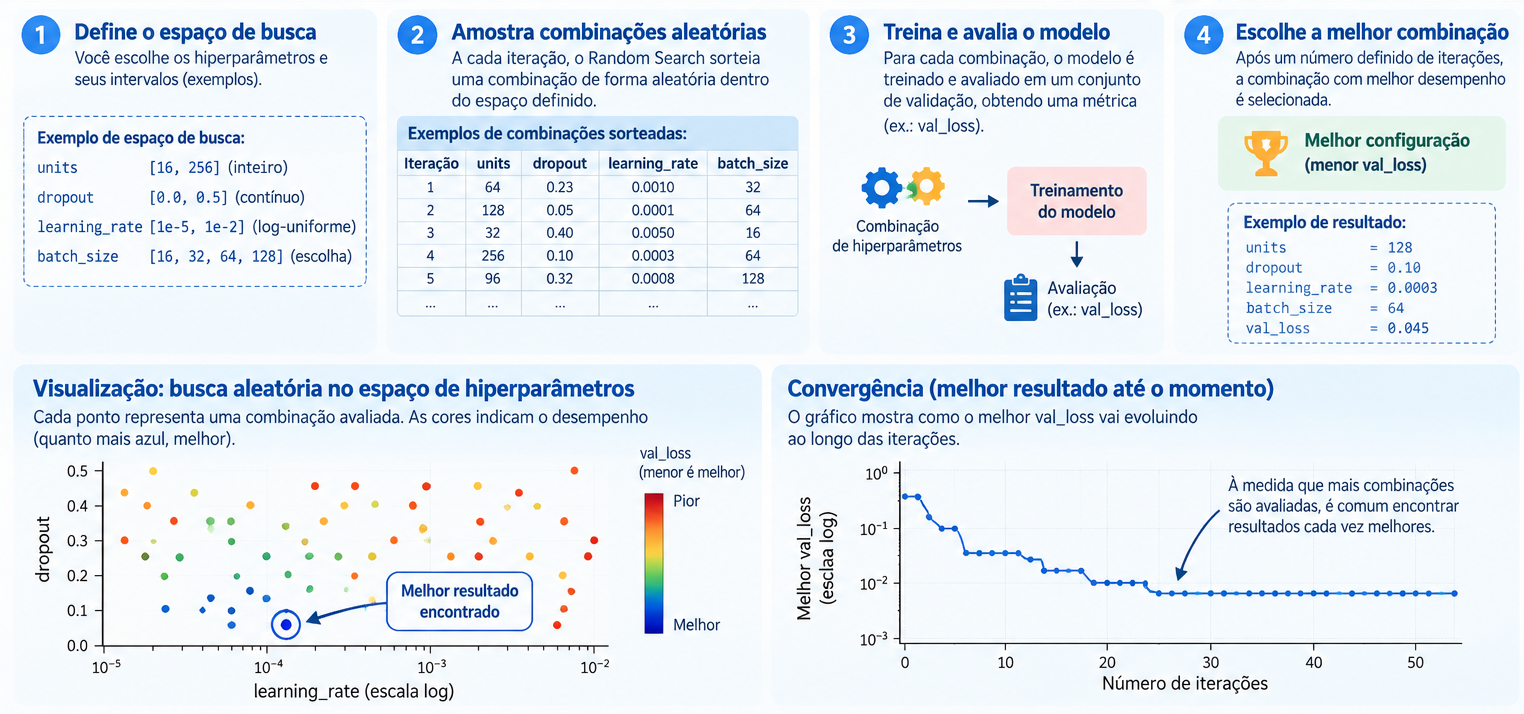

In [ ]:
# TODO crie uma função sample_random_config(rng) para gerar uma configuração
# aleatória de hiperparâmetros a partir do SEARCH_SPACE.
def sample_random_config(rng):

    # TODO sorteie aleatoriamente um valor de "units" entre os valores permitidos.
    # Converta o resultado para int.
    units = ...

    # TODO sorteie aleatoriamente um valor de "dropout" dentro do intervalo definido.
    # Converta o resultado para float.
    dropout = ...

    # TODO sorteie o "learning_rate" de forma log-uniforme entre os limites definidos.
    # Use log10 nos limites e depois 10** para voltar à escala original.
    learning_rate = ...

    # TODO sorteie aleatoriamente um valor de "batch_size" entre os valores permitidos.
    # Converta o resultado para int.
    batch_size = ...

    # TODO retorne os quatro hiperparâmetros em um dicionário.
    return {
        "units": ...,
        "dropout": ...,
        "learning_rate": ...,
        "batch_size": ...
    }

In [ ]:
rng = np.random.default_rng(SEED)
random_results = []

for trial in range(1, N_TRIALS + 1):
    params = sample_random_config(rng)
    result = train_one_config(params)

    random_results.append({
        "trial": trial,
        **params,
        "train_loss": result["best_train_loss"],
        "val_loss": result["best_val_loss"],
        "best_epoch": result["best_epoch"],
        "time_seconds": result["time_seconds"]
    })

    print(
        f"Trial {trial:02d}/{N_TRIALS} | "
        f"val_loss={result['best_val_loss']:.5f} | "
        f"units={params['units']} | "
        f"dropout={params['dropout']:.2f} | "
        f"lr={params['learning_rate']:.5f}"
    )

random_df = pd.DataFrame(random_results).sort_values("val_loss").reset_index(drop=True)

print("\nMelhores configurações do Random Search:")
display(random_df.head(5))

In [ ]:
random_by_trial = random_df.sort_values("trial")
curve_random = np.minimum.accumulate(random_by_trial["val_loss"].to_numpy())

plt.figure(figsize=(12, 5.5))
plt.scatter(
    random_by_trial["trial"],
    random_by_trial["val_loss"],
    s=100,
    alpha=0.8,
    label="Experimentos"
)
plt.plot(
    random_by_trial["trial"],
    curve_random,
    linewidth=2.5,
    label="Melhor valor acumulado"
)

best_trial = random_by_trial.loc[
    random_by_trial["val_loss"].idxmin()
]

plt.scatter(
    best_trial["trial"],
    best_trial["val_loss"],
    s=220,
    marker="*",
    label="Melhor trial"
)

plt.xlabel("Ordem do experimento")
plt.ylabel("MSE de validação")
plt.title("Random Search: evolução da melhor configuração encontrada")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(11, 6))

scatter = plt.scatter(
    random_df["learning_rate"],
    random_df["dropout"],
    c=random_df["val_loss"],
    s=random_df["units"] * 1.2,
    alpha=0.85
)

plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Dropout")
plt.title("Random Search: regiões de desempenho")
plt.colorbar(scatter, label="MSE de validação")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 8. Hyperopt com TPE

Agora usamos o **Tree-structured Parzen Estimator (TPE)**.

A diferença conceitual é importante:

```text
Random Search:
  escolhe uma configuração
  ↓
  mede o resultado
  ↓
  próxima configuração é independente
```

```text
TPE:
  escolhe uma configuração
  ↓
  mede o resultado
  ↓
  aprende com o histórico
  ↓
  direciona novas tentativas
```

Portanto, o foco não é apenas "testar muitos pontos", mas **usar os resultados anteriores para explorar melhor o espaço**.

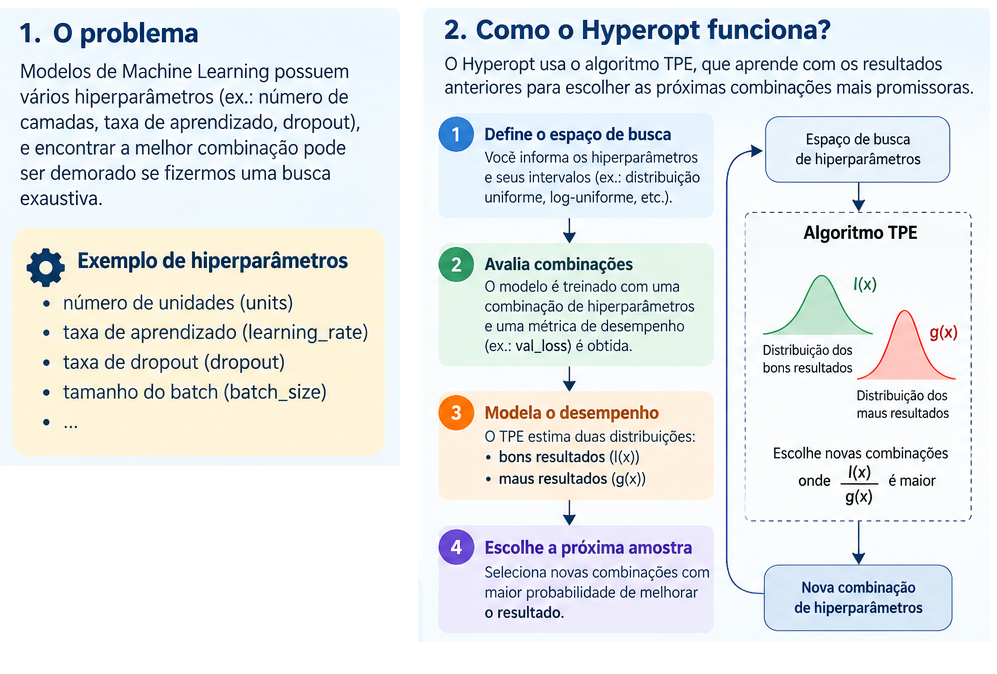

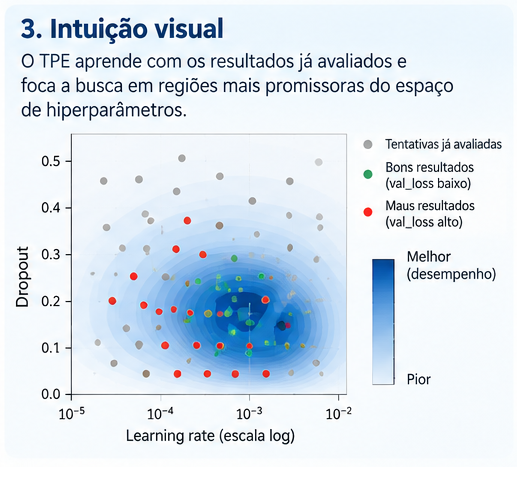

#### No detalhe

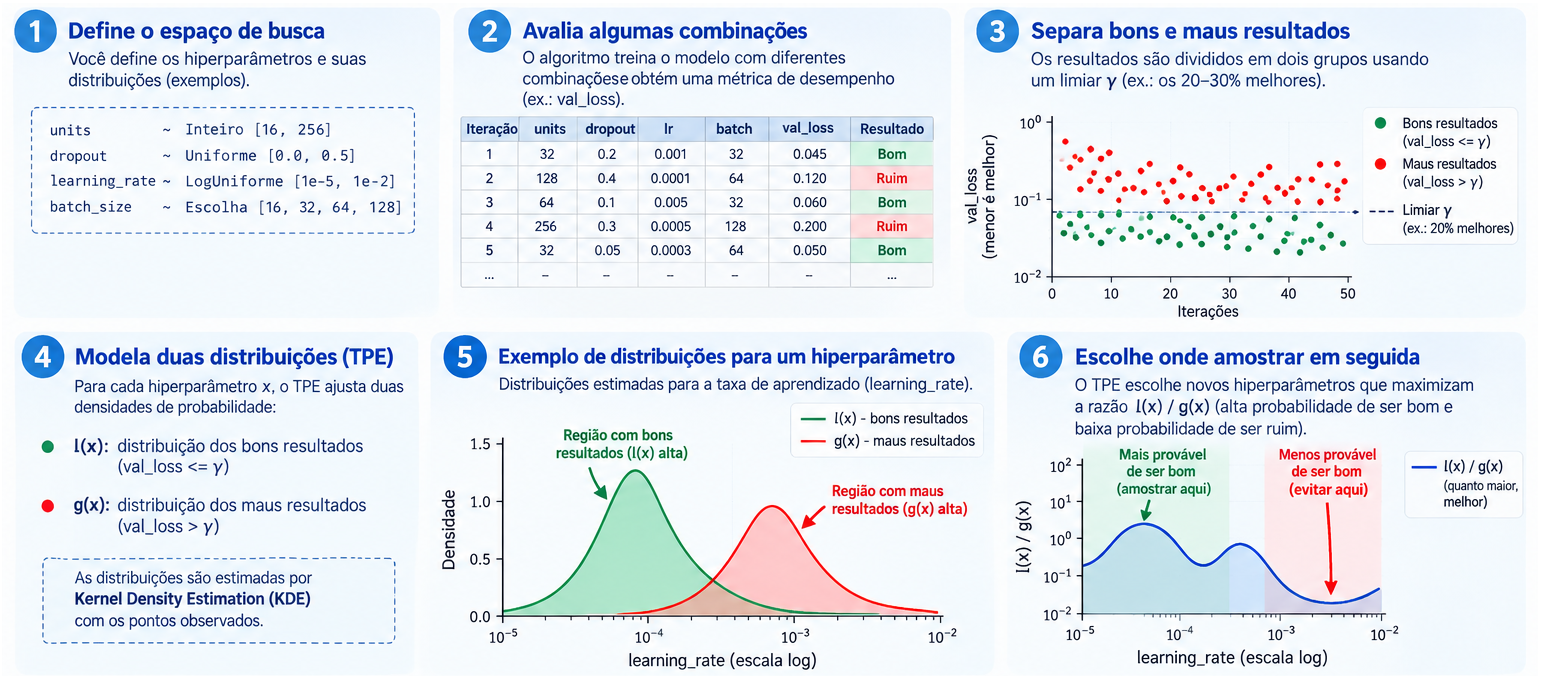

In [ ]:
# TODO crie o espaço de busca do Hyperopt a partir do SEARCH_SPACE.
# hp.choice seleciona valores discretos e hp.uniform amostra valores em um intervalo.
# hp.loguniform amostra o learning_rate em escala logarítmica.
hyperopt_space = {

    # TODO permita que o Hyperopt escolha entre os valores disponíveis de "units".
    "units": ...,

    # TODO permita que o Hyperopt sorteie "dropout" entre os limites definidos.
    "dropout": ...,

    # TODO permita que o Hyperopt sorteie "learning_rate" em escala logarítmica
    # entre os limites definidos em SEARCH_SPACE["learning_rate"].
    "learning_rate": ...,

    # TODO permita que o Hyperopt escolha entre os valores disponíveis de "batch_size".
    "batch_size": ...
}

In [ ]:
trials = Trials()

def objective(params):
    result = train_one_config(params)

    return {
        "loss": result["best_val_loss"],
        "status": STATUS_OK,
        "train_loss": result["best_train_loss"],
        "best_epoch": result["best_epoch"],
        "time_seconds": result["time_seconds"]
    }

In [ ]:
# TODO execute a busca de hiperparâmetros usando o algoritmo TPE do Hyperopt.
# TODO use objective como função objetivo, hyperopt_space como espaço de busca,
# max_evals=N_TRIALS como número máximo de tentativas e trials para armazenar os resultados.
# TODO use np.random.default_rng(SEED) para manter a reprodutibilidade dos resultados.
best_indices = fmin(
    fn=...,
    space=...,
    algo=...,
    max_evals=...,
    trials=...,
    rstate=...
)

# TODO converta os índices retornados pelo Hyperopt para os valores reais
# dos hiperparâmetros usando space_eval().
best_hyperopt_params = ...

print("Melhor configuração do TPE:")
print(best_hyperopt_params)

In [ ]:
hyperopt_results = []

for i, trial in enumerate(trials.trials, start=1):
    vals = trial["misc"]["vals"]

    units = SEARCH_SPACE["units"][vals["units"][0]]
    batch_size = SEARCH_SPACE["batch_size"][vals["batch_size"][0]]

    hyperopt_results.append({
        "trial": i,
        "units": units,
        "dropout": float(vals["dropout"][0]),
        "learning_rate": float(vals["learning_rate"][0]),
        "batch_size": batch_size,
        "train_loss": trial["result"]["train_loss"],
        "val_loss": trial["result"]["loss"],
        "best_epoch": trial["result"]["best_epoch"],
        "time_seconds": trial["result"]["time_seconds"]
    })

hyperopt_df = pd.DataFrame(hyperopt_results)

display(
    hyperopt_df.sort_values("val_loss").reset_index(drop=True).head(5)
)

In [ ]:
hyperopt_by_trial = hyperopt_df.sort_values("trial")
curve_hyperopt = np.minimum.accumulate(
    hyperopt_by_trial["val_loss"].to_numpy()
)

plt.figure(figsize=(12, 5.5))

plt.plot(
    random_by_trial["trial"],
    curve_random,
    marker="o",
    linewidth=2,
    label="Random Search"
)

plt.plot(
    hyperopt_by_trial["trial"],
    curve_hyperopt,
    marker="o",
    linewidth=2,
    label="Hyperopt / TPE"
)

plt.xlabel("Número de experimentos")
plt.ylabel("Melhor MSE de validação encontrado")
plt.title("Convergência das estratégias de otimização")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=(15, 5.5))

gs = fig.add_gridspec(
    1, 3,
    width_ratios=[1, 1, 0.05],
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharex=ax1, sharey=ax1)
cax = fig.add_subplot(gs[0, 2])

# Random Search
sc1 = ax1.scatter(
    random_df["learning_rate"],
    random_df["dropout"],
    c=random_df["val_loss"],
    s=random_df["units"] * 1.2,
    alpha=0.85
)

ax1.set_title("Random Search")
ax1.set_xlabel("Learning rate")
ax1.set_ylabel("Dropout")
ax1.set_xscale("log")
ax1.grid(alpha=0.25)

# Hyperopt / TPE
sc2 = ax2.scatter(
    hyperopt_df["learning_rate"],
    hyperopt_df["dropout"],
    c=hyperopt_df["val_loss"],
    s=hyperopt_df["units"] * 1.2,
    alpha=0.85
)

ax2.set_title("Hyperopt / TPE")
ax2.set_xlabel("Learning rate")
ax2.set_xscale("log")
ax2.grid(alpha=0.25)

# Dedicated colorbar axis
cbar = fig.colorbar(
    sc2,
    cax=cax
)

cbar.set_label("MSE de validação")

fig.suptitle(
    "Espaço de busca explorado pelas duas estratégias",
    y=1.02
)

plt.show()

# 9. Mapa diagnóstico: capacidade × generalização

Vamos usar duas grandezas:

- erro de treino;
- gap entre validação e treino.

\[
gap = MSE_{val} - MSE_{train}
\]

Este gráfico é uma **ferramenta diagnóstica**, e não uma medida matemática isolada de viés e variância.

In [ ]:
plt.figure(figsize=(8, 7))

plt.scatter(
    random_df["train_loss"],
    random_df["val_loss"],
    s=120,
    alpha=0.8
)

# Linha ideal: treino = validação
limite = max(
    random_df["train_loss"].max(),
    random_df["val_loss"].max()
)

plt.plot(
    [0, limite],
    [0, limite],
    linestyle="--",
    label="Treino = Validação"
)

plt.xlabel("MSE de treino")
plt.ylabel("MSE de validação")
plt.title("Relação entre erro de treino e validação")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

**Underfitting**

Erro de treino alto e validação também alta.

**Boa generalização**

Treino e validação baixos e próximos.

**Overfitting**

Treino muito baixo, mas validação significativamente maior.

# 10. Comparação das melhores configurações

A seleção dos hiperparâmetros deve ser feita pelo desempenho na **validação**.

O conjunto de teste permanece separado até a etapa final.

In [ ]:
best_random_row = random_df.iloc[0]

best_random_params = {
    "units": int(best_random_row["units"]),
    "dropout": float(best_random_row["dropout"]),
    "learning_rate": float(best_random_row["learning_rate"]),
    "batch_size": int(best_random_row["batch_size"])
}

comparison = pd.DataFrame([
    {
        "Estratégia": "Random Search",
        "Validation MSE": float(best_random_row["val_loss"]),
        **best_random_params
    },
    {
        "Estratégia": "Hyperopt / TPE",
        "Validation MSE": float(hyperopt_df["val_loss"].min()),
        **best_hyperopt_params
    }
])

display(comparison)

# 11. Treinamento final e avaliação no teste

Fluxo correto:

```text
TREINO
  ↓
aprende os pesos

VALIDAÇÃO
  ↓
escolhe hiperparâmetros

TESTE
  ↓
mede a generalização final
```

O objetivo do teste é responder como a configuração final se comporta em dados que não participaram da decisão de hiperparâmetros.

In [ ]:
if best_random_row["val_loss"] <= hyperopt_df["val_loss"].min():
    final_params = best_random_params
    selected_method = "Random Search"
else:
    final_params = best_hyperopt_params
    selected_method = "Hyperopt / TPE"

print("Método selecionado:", selected_method)
print("Hiperparâmetros:", final_params)

X_fit = np.concatenate([X_train, X_val], axis=0)
y_fit = np.concatenate([y_train, y_val], axis=0)

keras.backend.clear_session()
gc.collect()

final_model = create_lstm(
    units=final_params["units"],
    dropout=final_params["dropout"],
    learning_rate=final_params["learning_rate"]
)

final_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

history_final = final_model.fit(
    X_fit,
    y_fit,
    validation_split=0.10,
    epochs=FINAL_EPOCHS,
    batch_size=int(final_params["batch_size"]),
    verbose=0,
    callbacks=final_callbacks
)

test_pred = final_model.predict(X_test, verbose=0).ravel()

final_mse = mean_squared_error(y_test, test_pred)
final_rmse = np.sqrt(final_mse)
final_mae = mean_absolute_error(y_test, test_pred)

print(f"Teste — MSE : {final_mse:.5f}")
print(f"Teste — RMSE: {final_rmse:.5f}")
print(f"Teste — MAE : {final_mae:.5f}")

In [ ]:
N_SHOW = 500

plt.figure(figsize=(15, 5.5))

plt.plot(
    y_test[:N_SHOW],
    label="Observado",
    linewidth=2
)


plt.plot(
    test_pred[:N_SHOW],
    label="LSTM otimizada",
    linewidth=1.8,
    alpha=0.9
)

plt.title("Previsões no conjunto de teste")
plt.xlabel("Observações")
plt.ylabel("Consumo normalizado")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
N_ZOOM = 150

plt.figure(figsize=(15, 5))

plt.plot(
    y_test[:N_ZOOM],
    label="Observado",
    linewidth=2.5
)

plt.plot(
    test_pred[:N_ZOOM],
    label="LSTM otimizada",
    linewidth=2
)

plt.title("Zoom — observado × previsão")
plt.xlabel("Observações")
plt.ylabel("Consumo normalizado")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Referência

Salam, A.; El Hibaoui, A. (2018). **Power Consumption of Tetouan City**. UCI Machine Learning Repository. DOI: 10.24432/C5B034.

https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city